# 🩺 Chest X-ray Pneumonia Detection using DenseNet121

## 📌 Project Overview

Pneumonia is one of the leading causes of respiratory infections worldwide and remains a significant public health challenge. Early diagnosis through chest X-ray imaging can greatly improve treatment decisions and patient outcomes.

In this notebook, we develop an automated pneumonia detection system using **DenseNet121**, a pretrained convolutional neural network based on transfer learning.

The objective is to classify chest X-ray images into:

- ✅ Normal
- ❌ Pneumonia

The model is trained and evaluated using a carefully designed deep learning pipeline including preprocessing, data augmentation, transfer learning, fine-tuning, and comprehensive performance evaluation.

# 📚 Import Required Libraries

This section imports all required Python libraries used throughout the project.

The imported packages cover:

- Data manipulation
- Image preprocessing
- Deep learning model development
- Transfer learning
- Visualization
- Model evaluation

In [1]:
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split 
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings 
warnings.filterwarnings("ignore")

# 📂 Dataset Preparation

The dataset contains chest X-ray images collected for binary classification.

Each image belongs to one of the following categories:

- Normal
- Pneumonia

Image paths and corresponding labels are organized into a Pandas DataFrame to simplify preprocessing and integration with TensorFlow's data generators.

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
IMAGE_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)
LOSS_OPTIMIZER = 'binary_crossentropy'
METRICS='accuracy'

In [3]:
class_names = os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test')
class_names.reverse()
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

class_names, class_names_label

(['NORMAL', 'PNEUMONIA'], {'NORMAL': 0, 'PNEUMONIA': 1})

In [4]:
path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'
splits = ["train", "val", "test"]

def load_data():
    
    df_all = pd.DataFrame(columns = ['image_path', 'label'])
    
    # Iterate through training and test sets
    for split in splits:
        
        images_path = []
        label = []
        
        print("Loading {}".format(split))
        
        # Iterate through each folder corresponding to a category
        root = os.path.join(path, split)
        for folder in os.listdir(root):
            
            # Iterate through each image in our folder
            
            for file in tqdm(os.listdir(os.path.join(root, folder))):
                images_path.append(os.path.join(os.path.join(root, folder), file))
                label.append(folder)  
        
        df_conc = pd.DataFrame({
                "image_path": images_path,
                "label": label
            })
        df_all = pd.concat([df_conc, df_all], ignore_index=True)

    return df_all

In [5]:
df_all = load_data()
df_all

Loading train


100%|██████████| 1341/1341 [00:00<00:00, 552456.70it/s]


Loading val


100%|██████████| 8/8 [00:00<00:00, 64776.90it/s]

Loading test



100%|██████████| 234/234 [00:00<00:00, 564061.57it/s]


,image_path,label
0,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
1,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
2,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
3,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
4,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
...,...,...
5851,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL
5852,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL
5853,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL
5854,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL


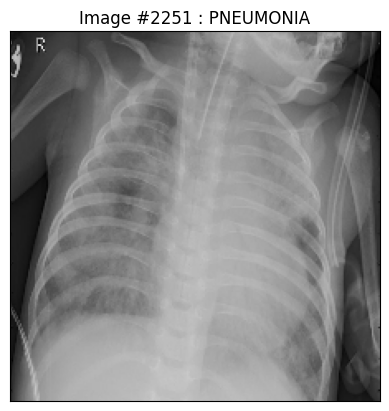

In [6]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """
    
    images = images.to_numpy()
    labels = labels.to_numpy()
    
    index = np.random.randint(len(images))
    plt.figure()
    
    img = cv2.imread(images[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE) 
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f"Image #{index} : {labels[index]}")
    plt.show()

display_random_image(class_names, df_all['image_path'], df_all['label'])

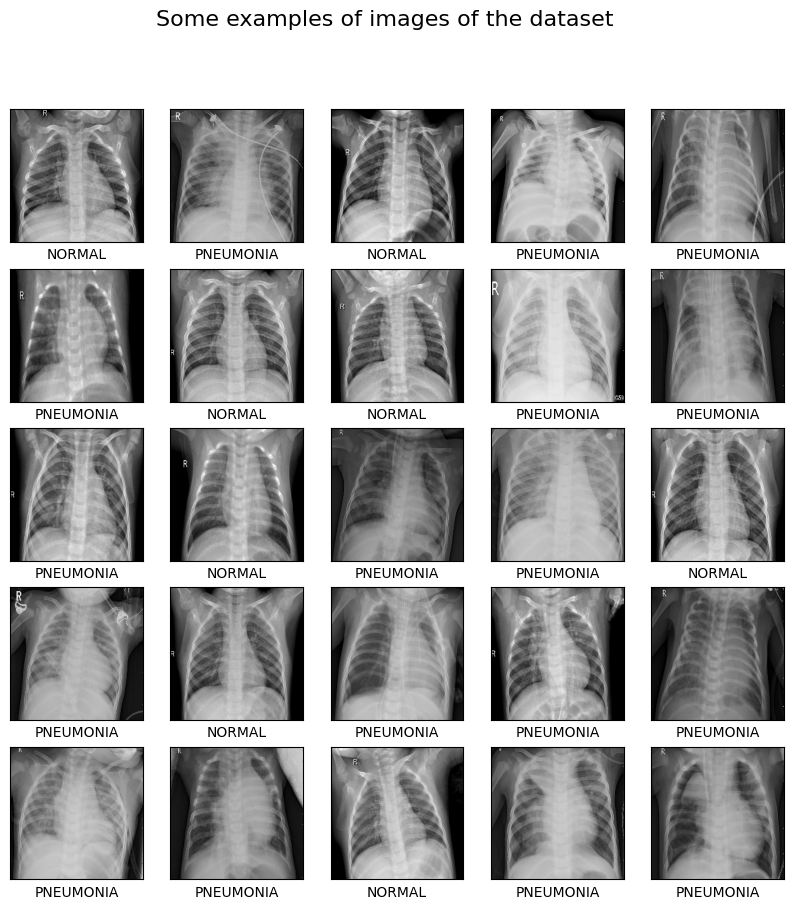

In [7]:
def display_examples(class_names, images, labels):
    """
        Display 25 random images from the images array with its corresponding labels
    """
    
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        index = i + random.choice(range(images.shape[0])) - 25
        img = cv2.imread(images[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SIZE)
        plt.imshow(img)
        plt.xlabel(labels[index])
    plt.show()

display_examples(class_names, df_all['image_path'], df_all['label'])

# 🔀 Train, Validation and Test Split

The dataset is divided into three subsets:

- Training Set
- Validation Set
- Test Set

A **stratified split** is applied to preserve the original class distribution across all subsets, ensuring a fair and reliable evaluation.

In [8]:
df_train, df_test = train_test_split(
    df_all,
    test_size=0.1,
    stratify=df_all["label"],
    random_state=42
)

df_train, df_val = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train["label"],
    random_state=42
)

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

Train size: 4743
Val size: 527
Test size: 586


# 🎨 Data Augmentation for DenseNet121

To improve model generalization and reduce overfitting, data augmentation is applied only to the training dataset.

The following transformations are used:

- Small random rotations
- Width shifting
- Height shifting
- Shear transformation
- Zoom augmentation

Validation and test datasets remain unchanged except for preprocessing, allowing an unbiased evaluation.

In [9]:
dense_train_datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.01,
    height_shift_range=0.01,
    shear_range=0.05,
    zoom_range=0.1,
    preprocessing_function=dense_preprocess_input,
    horizontal_flip=False,
    fill_mode="constant",         
    cval=0
)

dense_val_datagen = ImageDataGenerator(preprocessing_function=dense_preprocess_input)

dense_train_gen = dense_train_datagen.flow_from_dataframe(
    dataframe = df_train,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "binary",
    shuffle = True,
    batch_size = BATCH_SIZE,
    seed = 42
)

dense_val_gen = dense_val_datagen.flow_from_dataframe(
    dataframe = df_val,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "binary",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)
dense_test_gen = dense_val_datagen.flow_from_dataframe(
    dataframe = df_test,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "binary",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)

Found 4743 validated image filenames belonging to 2 classes.
Found 527 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.


# 🧠 DenseNet121 Architecture

DenseNet121 is a deep convolutional neural network pretrained on the ImageNet dataset.

Instead of training a network from scratch, transfer learning is employed to leverage the rich feature representations learned from millions of natural images.

The convolutional backbone is initially frozen while a custom classification head is trained.

Later, selective fine-tuning is performed to further adapt the network to the chest X-ray classification task.

In [10]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape= IMAGE_SHAPE
)

I0000 00:00:1783088466.416902      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783088466.419881      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

dense_model = Model(inputs=base_model.input,
              outputs=output)

# ⚙️ Model Compilation

The model is compiled using:

- Adam optimizer
- Binary Crossentropy loss
- Accuracy as the primary evaluation metric

This configuration is well suited for binary medical image classification.

In [12]:
dense_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "DenseNet121_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# 🚀 Model Training

The network is trained using the augmented training dataset.

To improve convergence and avoid overfitting, the following callbacks are employed:

- Early Stopping
- Learning Rate Reduction
- Model Checkpointing

These strategies help preserve the best-performing model during training.

In [14]:
dense_history = dense_model.fit(
    dense_train_gen,
    validation_data=dense_val_gen,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
  1/149 ━━━━━━━━━━━━━━━━━━━━ 1:08:52 28s/step - accuracy: 0.3438 - loss: 1.4013

I0000 00:00:1783088499.966705      76 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7683 - loss: 0.5098 - val_accuracy: 0.9108 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 94s 627ms/step - accuracy: 0.8813 - loss: 0.2812 - val_accuracy: 0.9450 - val_loss: 0.1724 - learning_rate: 0.0010
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 92s 615ms/step - accuracy: 0.9022 - loss: 0.2386 - val_accuracy: 0.9507 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 623ms/step - accuracy: 0.9140 - loss: 0.2147 - val_accuracy: 0.9583 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 625ms/step - accuracy: 0.9199 - loss: 0.2052 - val_accuracy: 0.9583 - val_loss: 0.1315 - learning_rate: 0.0010
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 91s 612ms/step - accuracy: 0.9190 - loss: 0.1936 - val_accuracy: 0.9545 - val_loss: 0.1261 - learning_rate: 0.0010
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 623ms/step - accuracy: 0.9252 - loss: 0

In [15]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

dense_model.compile(
    optimizer=Adam(1e-4),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

dense_history_finetune = dense_model.fit(
    dense_train_gen,
    validation_data=dense_val_gen,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 155s 843ms/step - accuracy: 0.9220 - loss: 0.2373 - val_accuracy: 0.9507 - val_loss: 0.1258 - learning_rate: 1.0000e-04
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 94s 627ms/step - accuracy: 0.9445 - loss: 0.1710 - val_accuracy: 0.9753 - val_loss: 0.0820 - learning_rate: 1.0000e-04
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 622ms/step - accuracy: 0.9505 - loss: 0.1347 - val_accuracy: 0.9677 - val_loss: 0.0891 - learning_rate: 1.0000e-04
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 92s 619ms/step - accuracy: 0.9524 - loss: 0.1363 - val_accuracy: 0.9734 - val_loss: 0.0849 - learning_rate: 1.0000e-04
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 621ms/step - accuracy: 0.9551 - loss: 0.1171 - val_accuracy: 0.9791 - val_loss: 0.0729 - learning_rate: 1.0000e-04
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 94s 630ms/step - accuracy: 0.9595 - loss: 0.1103 - val_accuracy: 0.9810 - val_loss: 0.0715 - learning_rate: 1.0000e-04
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 92s 6

# 📈 Model Evaluation

After training, the model is evaluated on the unseen test dataset.

Several evaluation metrics are reported, including:

- Test Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a comprehensive assessment of the model's diagnostic performance.

In [16]:
print("Train class evaluate :", dense_model.evaluate(dense_train_gen))
print("Val class evaluate :", dense_model.evaluate(dense_val_gen))
print("Test class evaluate :", dense_model.evaluate(dense_test_gen))

149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 625ms/step - accuracy: 0.9817 - loss: 0.0524
Train class evaluate : [0.052439432591199875, 0.9816572070121765]
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 289ms/step - accuracy: 0.9810 - loss: 0.0715
Val class evaluate : [0.07153938710689545, 0.9810246825218201]
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9454 - loss: 0.1411
Test class evaluate : [0.14108766615390778, 0.9453924894332886]


In [17]:
dense_test_gen.reset()

y_prob = dense_model.predict(dense_test_gen)
y_pred = (y_prob > 0.5).astype(int).flatten()

y_true = dense_test_gen.classes

19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 892ms/step


# 📊 Confusion Matrix Analysis

The confusion matrix summarizes the model's predictions across both classes.

Special attention is given to:

- False Positives (FP)
- False Negatives (FN)

In medical diagnosis, minimizing false negatives is particularly important, as missed pneumonia cases may delay treatment and increase clinical risk.

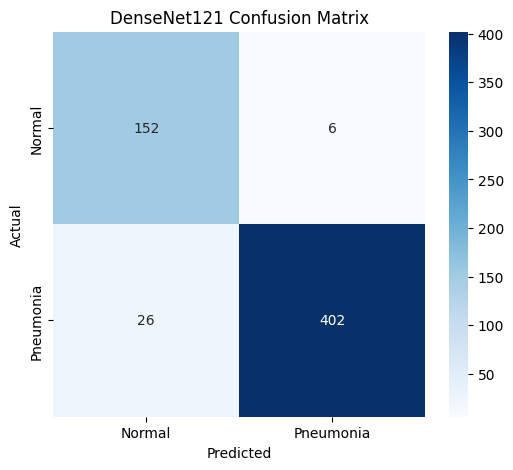

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 Confusion Matrix")
plt.show()

# 📑 Classification Report

The classification report presents detailed performance metrics for each class.

The reported metrics include:

- Precision
- Recall
- F1-score
- Support

These measures provide deeper insight than overall accuracy alone.

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal","Pneumonia"]
))

              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90       158
   Pneumonia       0.99      0.94      0.96       428

    accuracy                           0.95       586
   macro avg       0.92      0.95      0.93       586
weighted avg       0.95      0.95      0.95       586



# 🏆 Model Comparison

To identify the most suitable model for deployment, three deep learning architectures were evaluated under identical experimental conditions.

The comparison included:

| Model | Test Accuracy | Precision | Recall | False Positives | False Negatives |
|--------|--------------:|----------:|--------:|----------------:|----------------:|
| Custom CNN | 97.53% | 97.6% | 95.3% | 10 | 20 |
| DenseNet121 | 97.34% | 99% | 94% | 4 | 26 |
| EfficientNetB0 | 97.95% | 97.64% | 96.72% | 10 | 14 |

### 📌 Discussion

Each model exhibits different strengths.

- **EfficientNetB0** achieved the best overall balance between precision, recall, and accuracy, making it the strongest candidate for deployment.
- **DenseNet121** demonstrated the highest Precision, successfully identifying more normal cases while producing more false Negatives, making it less suitable for medical screening applications.
- **Custom CNN** achieved balance between precision and recall but suffered from a considerably higher false-negative rate.

Considering all evaluation metrics, **the EfficientNetB0 model was selected as the final deployment model** due to its superior overall performance and balanced diagnostic capability.